<a href="https://colab.research.google.com/github/kursatkara/MAE_5020_Spring_2026/blob/master/06_Notebook_B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Notebook B — Training as a Dynamical System

## 🎯 Learning Objective

Extend the one-step neural network update from Notebook A to many steps and interpret training as a **discrete-time dynamical system in parameter space**.

We will study the update
$$
\theta_{k+1} = \theta_k - \eta \nabla_\theta L(\theta_k),
$$
where:
- $\theta$ denotes the collection of parameters,
- $\eta$ is the learning rate,
- $L(\theta)$ is the loss function.

---

## 🧠 Challenge

One gradient update worked in Notebook A.

But what happens if we repeat that update many times?

- Does the loss always decrease?
- How do the parameters evolve?
- What role does the learning rate $\eta$ play?
- When does training become unstable?

The goal of this notebook is not just to run a training loop.  
The goal is to **understand the dynamics of training**.



## 🔹 Model and Loss

We use the same simple network as before:

$$
z^1 = W^1 x + b^1
$$
$$
a^1 = \sigma(z^1)
$$
$$
z^2 = W^2 a^1 + b^2
$$
$$
\hat{y} = \sigma(z^2)
$$

with loss
$$
L = \frac{1}{2}(\hat{y} - y)^2.
$$

This is intentionally small so that we can inspect the training behavior carefully.

---

## 🔹 Why This Matters

In larger neural networks, the same logic applies, but the parameter space is much higher dimensional.  
This notebook helps build intuition in the simplest setting before moving to richer datasets and larger architectures.


In [1]:

import torch
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)

plt.rcParams["figure.figsize"] = (7, 4)



## 🔹 Problem Setup

We again use a single training pair:
- input $x = 1.0$
- target $y = 0.0$

This setup is simple enough that we can inspect every important quantity:
- the loss,
- the gradient norm,
- the parameter trajectories,
- the predicted output.

We will begin with fixed initial parameters so that the behavior is reproducible and easy to discuss in class.


In [2]:

# Single training pair
x = torch.tensor([1.0])
y = torch.tensor([0.0])

# Initial parameters (same spirit as Notebook A)
W1_init = 0.5
b1_init = 0.0
W2_init = 0.5
b2_init = 0.0

def sigmoid(z):
    return torch.sigmoid(z)

def forward_scalar_network(W1, b1, W2, b2, x):
    # Hidden layer
    z1 = W1 * x + b1
    a1 = sigmoid(z1)

    # Output layer
    z2 = W2 * a1 + b2
    y_hat = sigmoid(z2)

    return z1, a1, z2, y_hat

def loss_fn(y_hat, y):
    return 0.5 * (y_hat - y) ** 2



## 🔹 A Reusable Training Function

Instead of writing a one-off loop, we wrap the logic in a function.

This helps us:
1. run multiple experiments cleanly,
2. compare different learning rates,
3. separate the **training method** from the **interpretation**.

The function below records the full training history:
- loss,
- prediction $\hat{y}$,
- parameter values,
- gradient norm.

That history will be the basis for our analysis.


In [3]:

def train_single_sample(lr=0.1, epochs=50):
    # Parameters with gradients enabled
    W1 = torch.tensor(W1_init, dtype=torch.float32, requires_grad=True)
    b1 = torch.tensor(b1_init, dtype=torch.float32, requires_grad=True)
    W2 = torch.tensor(W2_init, dtype=torch.float32, requires_grad=True)
    b2 = torch.tensor(b2_init, dtype=torch.float32, requires_grad=True)

    history = {
        "epoch": [],
        "loss": [],
        "y_hat": [],
        "W1": [],
        "b1": [],
        "W2": [],
        "b2": [],
        "grad_norm": [],
    }

    for epoch in range(epochs):
        # Forward pass
        z1, a1, z2, y_hat = forward_scalar_network(W1, b1, W2, b2, x)
        loss = loss_fn(y_hat, y)

        # Backward pass
        loss.backward()

        # Compute gradient norm before parameters are updated or cleared
        grad_norm = torch.sqrt(W1.grad**2 + b1.grad**2 + W2.grad**2 + b2.grad**2)

        # Store current state
        history["epoch"].append(epoch)
        history["loss"].append(loss.item())
        history["y_hat"].append(y_hat.item())
        history["W1"].append(W1.item())
        history["b1"].append(b1.item())
        history["W2"].append(W2.item())
        history["b2"].append(b2.item())
        history["grad_norm"].append(grad_norm.item())

        # Gradient descent update
        with torch.no_grad():
            W1 -= lr * W1.grad
            b1 -= lr * b1.grad
            W2 -= lr * W2.grad
            b2 -= lr * b2.grad

        # Clear gradients for the next iteration
        W1.grad.zero_()
        b1.grad.zero_()
        W2.grad.zero_()
        b2.grad.zero_()

    return history



## 🔹 Baseline Experiment

We begin with a moderate learning rate:
$$
\eta = 0.1.
$$

This should give stable training for this small example.

As you review the output, pay attention to three questions:
1. Is the loss decreasing?
2. Are the gradients remaining nonzero?
3. Are the parameter changes becoming smaller as training proceeds?


In [4]:

history_baseline = train_single_sample(lr=0.1, epochs=50)

print("Initial loss:", history_baseline["loss"][0])
print("Final loss  :", history_baseline["loss"][-1])
print("Initial prediction:", history_baseline["y_hat"][0])
print("Final prediction  :", history_baseline["y_hat"][-1])


Initial loss: 0.1665714830160141
Final loss  : 0.07303915917873383
Initial prediction: 0.5771853923797607
Final prediction  : 0.3822019398212433



## 🔹 Visualizing the Training Dynamics

The most common plot in machine learning is the loss curve.  
That is useful, but it is not enough.

We also want to inspect:
- parameter trajectories,
- gradient norm,
- prediction evolution.

This is the key pedagogical point of the notebook:

> Training is not just “loss going down.”  
> Training is a trajectory in parameter space.


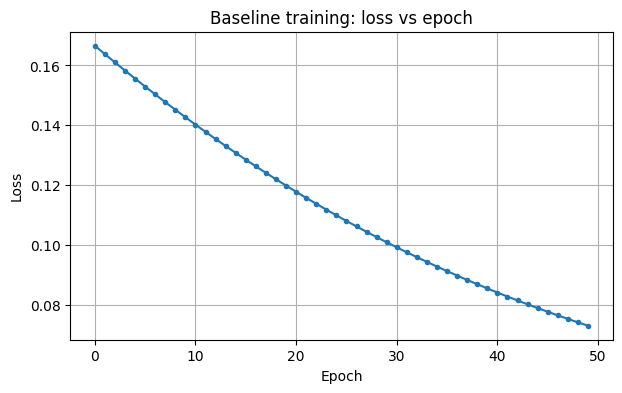

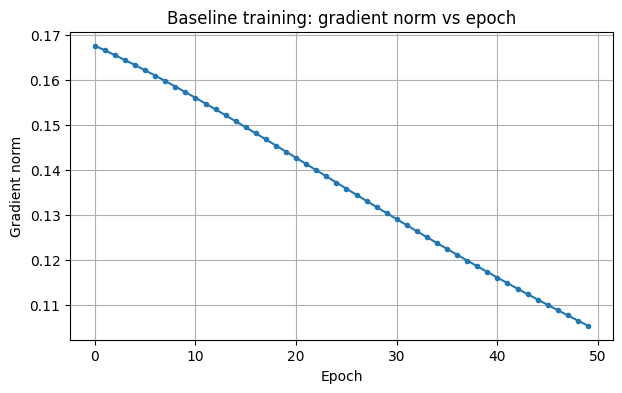

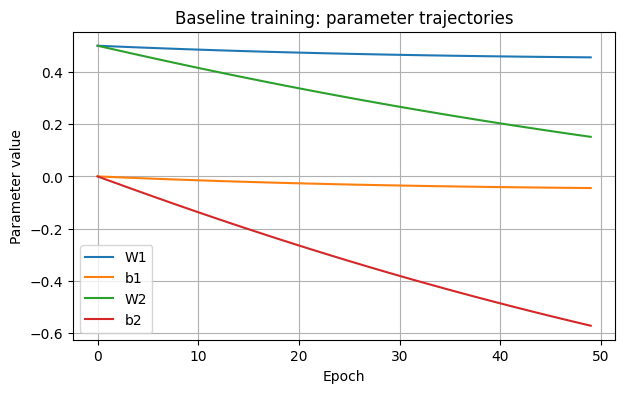

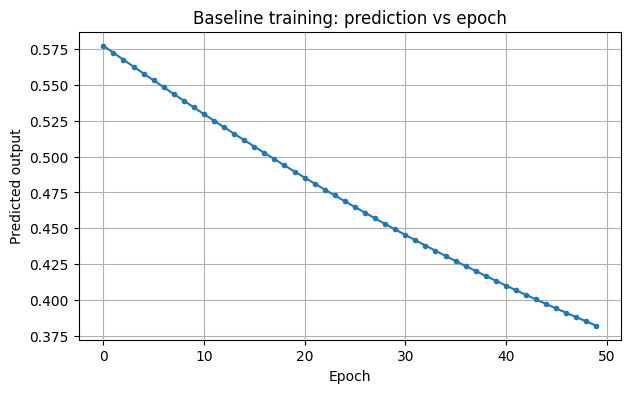

In [5]:

epochs = history_baseline["epoch"]

plt.figure()
plt.plot(epochs, history_baseline["loss"], marker="o", markersize=3)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline training: loss vs epoch")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(epochs, history_baseline["grad_norm"], marker="o", markersize=3)
plt.xlabel("Epoch")
plt.ylabel("Gradient norm")
plt.title("Baseline training: gradient norm vs epoch")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(epochs, history_baseline["W1"], label="W1")
plt.plot(epochs, history_baseline["b1"], label="b1")
plt.plot(epochs, history_baseline["W2"], label="W2")
plt.plot(epochs, history_baseline["b2"], label="b2")
plt.xlabel("Epoch")
plt.ylabel("Parameter value")
plt.title("Baseline training: parameter trajectories")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(epochs, history_baseline["y_hat"], marker="o", markersize=3)
plt.xlabel("Epoch")
plt.ylabel("Predicted output")
plt.title("Baseline training: prediction vs epoch")
plt.grid(True)
plt.show()



## 🔍 Sanity Check

At this point, verify the following:

- Are the gradients nonzero at the beginning?
- Does the loss decrease over training?
- Does the prediction move toward the target value $y=0$?
- Do the parameter updates become smaller as the gradient norm decreases?

These checks are simple, but they are essential.  
When training larger models, many failures can be caught early by asking these same questions.



## 🔹 Interpreting Training as a Dynamical System

The update
$$
\theta_{k+1} = \theta_k - \eta \nabla_\theta L(\theta_k)
$$
defines a **discrete-time dynamical system**.

This viewpoint is valuable because it shifts the conversation from “running code” to “analyzing behavior.”

Some useful interpretations:

- If $\eta$ is too small, the system evolves very slowly.
- If $\eta$ is chosen well, the system moves toward a minimum of the loss.
- If $\eta$ is too large, the system may oscillate or diverge.

This language should feel familiar from numerical methods and dynamical systems analysis.



## 🔹 Learning Rate Experiment

We now compare three cases:

1. **Small learning rate**  
   $$\eta = 0.01$$  
   Expect slow but stable progress.

2. **Moderate learning rate**  
   $$\eta = 0.1$$  
   Expect stable and faster convergence.

3. **Large learning rate**  
   $$\eta = 2.0$$  
   This may produce unstable behavior, overshoot, or oscillation.

The purpose is not just to see different curves.  
The purpose is to understand how the update rule depends on step size.


In [6]:

hist_small = train_single_sample(lr=0.01, epochs=50)
hist_medium = train_single_sample(lr=0.1, epochs=50)
hist_large = train_single_sample(lr=2.0, epochs=50)


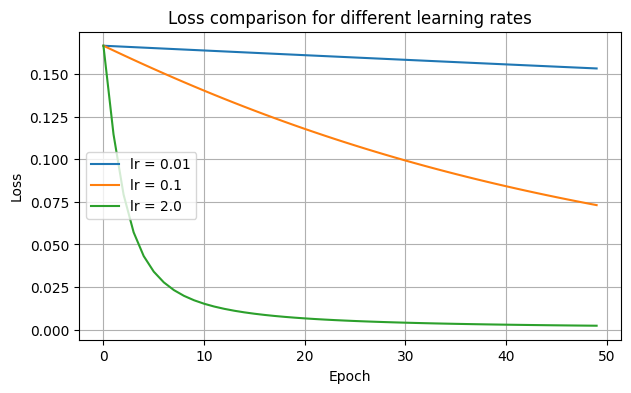

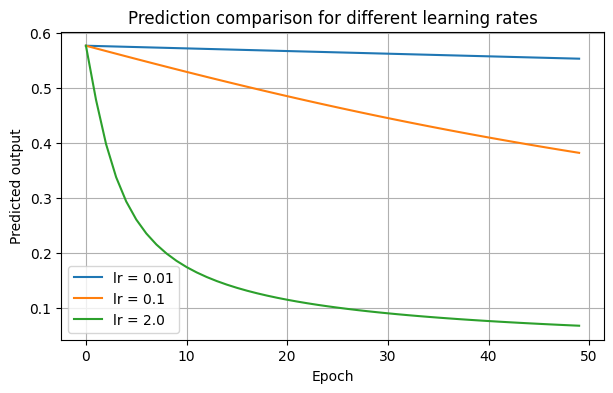

In [7]:

plt.figure()
plt.plot(hist_small["epoch"], hist_small["loss"], label="lr = 0.01")
plt.plot(hist_medium["epoch"], hist_medium["loss"], label="lr = 0.1")
plt.plot(hist_large["epoch"], hist_large["loss"], label="lr = 2.0")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss comparison for different learning rates")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(hist_small["epoch"], hist_small["y_hat"], label="lr = 0.01")
plt.plot(hist_medium["epoch"], hist_medium["y_hat"], label="lr = 0.1")
plt.plot(hist_large["epoch"], hist_large["y_hat"], label="lr = 2.0")
plt.xlabel("Epoch")
plt.ylabel("Predicted output")
plt.title("Prediction comparison for different learning rates")
plt.legend()
plt.grid(True)
plt.show()



## 🔹 Summary Table

A concise summary can help students connect the plots to the underlying behavior.


In [8]:

def summarize(history, lr):
    return {
        "learning_rate": lr,
        "initial_loss": history["loss"][0],
        "final_loss": history["loss"][-1],
        "initial_y_hat": history["y_hat"][0],
        "final_y_hat": history["y_hat"][-1],
        "final_grad_norm": history["grad_norm"][-1],
    }

summaries = [
    summarize(hist_small, 0.01),
    summarize(hist_medium, 0.1),
    summarize(hist_large, 2.0),
]

for row in summaries:
    print(row)


{'learning_rate': 0.01, 'initial_loss': 0.1665714830160141, 'final_loss': 0.1532323956489563, 'initial_y_hat': 0.5771853923797607, 'final_y_hat': 0.5535926222801208, 'final_grad_norm': 0.1622363179922104}
{'learning_rate': 0.1, 'initial_loss': 0.1665714830160141, 'final_loss': 0.07303915917873383, 'initial_y_hat': 0.5771853923797607, 'final_y_hat': 0.3822019398212433, 'final_grad_norm': 0.10540827363729477}
{'learning_rate': 2.0, 'initial_loss': 0.1665714830160141, 'final_loss': 0.0022810243535786867, 'initial_y_hat': 0.5771853923797607, 'final_y_hat': 0.06754294037818909, 'final_grad_norm': 0.005179869011044502}



## 🔹 What to Notice

As you compare the experiments, ask:

- Which learning rate gives the fastest stable decrease in loss?
- Does the largest learning rate produce smooth convergence?
- How does the prediction $\hat{y}$ behave in each case?
- What does the gradient norm tell us about progress?

This is the kind of reasoning students should practice repeatedly:
not just reading curves, but interpreting them.



## 🔹 Optional Extension: Inspect the First Few Updates

Sometimes students benefit from seeing the first few iterations explicitly, especially after a conceptual lecture.

The code below prints the first few epochs for the baseline run.  
This is often useful in class discussion because it connects the training loop back to the one-step calculation in Notebook A.


In [9]:

for i in range(5):
    print(
        f"epoch={history_baseline['epoch'][i]:2d}, "
        f"loss={history_baseline['loss'][i]:.6f}, "
        f"y_hat={history_baseline['y_hat'][i]:.6f}, "
        f"W1={history_baseline['W1'][i]:.6f}, "
        f"b1={history_baseline['b1'][i]:.6f}, "
        f"W2={history_baseline['W2'][i]:.6f}, "
        f"b2={history_baseline['b2'][i]:.6f}, "
        f"grad_norm={history_baseline['grad_norm'][i]:.6f}"
    )


epoch= 0, loss=0.166571, y_hat=0.577185, W1=0.500000, b1=0.000000, W2=0.500000, b2=0.000000, grad_norm=0.167560
epoch= 1, loss=0.163772, y_hat=0.572315, W1=0.498345, b1=-0.001655, W2=0.491232, b2=-0.014086, grad_norm=0.166531
epoch= 2, loss=0.161008, y_hat=0.567464, W1=0.496726, b1=-0.003274, W2=0.482523, b2=-0.028094, grad_norm=0.165468
epoch= 3, loss=0.158279, y_hat=0.562635, W1=0.495145, b1=-0.004856, W2=0.473875, b2=-0.042023, grad_norm=0.164375
epoch= 4, loss=0.155586, y_hat=0.557828, W1=0.493599, b1=-0.006401, W2=0.465289, b2=-0.055868, grad_norm=0.163252



## 🔹 Reflection Questions

1. Why is it useful to view gradient descent as a dynamical system?
2. Why does a very small learning rate usually remain stable but converge slowly?
3. Why can a large learning rate lead to oscillation or divergence?
4. In this single-sample problem, what does “convergence” mean physically?
5. Which plot is more informative: loss, prediction, gradient norm, or parameter trajectory? Why?

These questions are meant to shift students from implementation to interpretation.



## 🧠 Engineering Takeaway

Training a neural network is not just an algebraic procedure.  
It is an **iterative nonlinear parameter estimation process**.

The update
$$
\theta_{k+1} = \theta_k - \eta \nabla_\theta L(\theta_k)
$$
is mathematically similar in spirit to many iterative methods used in engineering:
- gradient-based optimization,
- inverse problems,
- parameter calibration,
- sensitivity-driven design.

Understanding that structure is more important than memorizing the code.



## 🚀 Next

In the next notebook, we will move from a single training pair to a small dataset and ask a deeper question:

> Can the network learn a function rather than just reduce the error on one point?

That shift takes us from “one-step mechanics” to **generalization**.
